In [1]:
# import library
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# load dataset 
df_market = pd.read_csv('marketing_campaign_performance_10000.csv')
df_market

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86
...,...,...,...,...,...,...,...,...,...,...,...
9995,CAMP09996,2025-05-28,2025-06-03,Influencer,112030,1896,627,152,4491.36,12415.83,1.76
9996,CAMP09997,2025-12-31,2026-01-06,Search,177412,11529,2021,955,761.85,1214.01,0.59
9997,CAMP09998,2025-12-30,2026-01-07,Social,41892,4098,940,470,116.84,339.12,1.90
9998,CAMP09999,2025-05-20,2025-05-28,Social,141674,10697,1834,385,2885.00,6580.54,1.28


In [3]:
df_market.info()        # Startdate dan EndDate belom menjadi datetime type nya jadi harus diubah dulu

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  str    
 1   StartDate    10000 non-null  str    
 2   EndDate      10000 non-null  str    
 3   Channel      10000 non-null  str    
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), str(4)
memory usage: 859.5 KB


In [4]:
df_market['StartDate'] = pd.to_datetime(df_market['StartDate'],errors="coerce")
df_market['EndDate'] = pd.to_datetime(df_market['EndDate'], errors="coerce")


In [5]:
df_market.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CampaignID   10000 non-null  str           
 1   StartDate    10000 non-null  datetime64[us]
 2   EndDate      10000 non-null  datetime64[us]
 3   Channel      10000 non-null  str           
 4   Impressions  10000 non-null  int64         
 5   Clicks       10000 non-null  int64         
 6   Leads        10000 non-null  int64         
 7   Conversions  10000 non-null  int64         
 8   Cost_USD     10000 non-null  float64       
 9   Revenue_USD  10000 non-null  float64       
 10  ROI          10000 non-null  float64       
dtypes: datetime64[us](2), float64(3), int64(4), str(2)
memory usage: 859.5 KB


In [6]:
df_market['StartDate'] = df_market['StartDate'].dt.month
df_market['EndDate'] = df_market['EndDate'].dt.month


In [7]:
df_market

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,4,4,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,12,12,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,9,10,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,4,4,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,3,3,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86
...,...,...,...,...,...,...,...,...,...,...,...
9995,CAMP09996,5,6,Influencer,112030,1896,627,152,4491.36,12415.83,1.76
9996,CAMP09997,12,1,Search,177412,11529,2021,955,761.85,1214.01,0.59
9997,CAMP09998,12,1,Social,41892,4098,940,470,116.84,339.12,1.90
9998,CAMP09999,5,5,Social,141674,10697,1834,385,2885.00,6580.54,1.28


In [15]:
biaya_bulan = df_market.groupby(['StartDate'])['Cost_USD'].sum()
pendapatan_bulan = df_market.groupby(['StartDate'])['Revenue_USD'].sum()

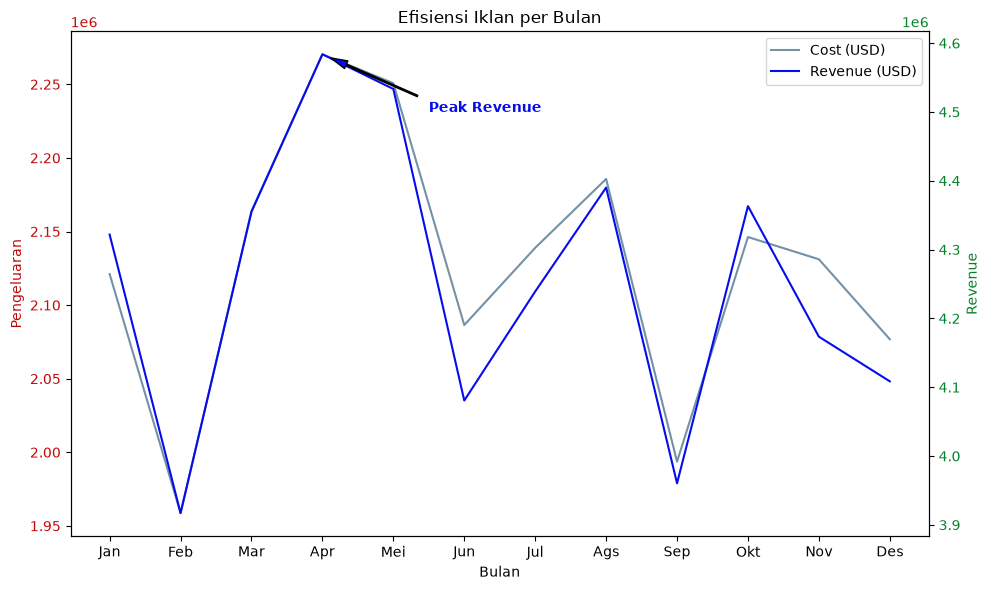

In [40]:
# base plot (axes)
figure, axes = plt.subplots(figsize=(10, 6))

# plot pertama
axes.plot(biaya_bulan.index, biaya_bulan.values,color='#7491a6',
                                                label='Cost (USD)')

axes.set_xlabel("Bulan")
axes.set_ylabel("Pengeluaran", color='#c20a0a')
axes.tick_params(axis='y', labelcolor='#c20a0a')

# plot kedua
axes2 = axes.twinx()
axes2.plot(pendapatan_bulan.index,pendapatan_bulan.values,color='#050ced',
                                                        label='Revenue (USD)')

axes2.set_ylabel('Revenue', color='#04822c')
axes2.tick_params(axis='y', labelcolor='#04822c')

# membuat title
axes.set_title('Efisiensi Iklan per Bulan')
axes2.annotate('Peak Revenue', 
             xy=(4, pendapatan_bulan[4]), 
             xytext=(5.5, 4500000),
             arrowprops=dict(facecolor='#050ced', shrink=0.08, width=1, headwidth=6),
             color='#050ced', fontweight='bold')
axes.set_xticks(biaya_bulan.index)
axes.set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des'])
plt.tight_layout()
lines1, label1 = axes.get_legend_handles_labels()
lines2, label2 = axes2.get_legend_handles_labels()    
axes.legend(lines1+lines2, label1 + label2)
plt.show()
                                                



